# Ethiopia Climate EDA

NASA Climate Dataset for Ethiopia (2015–2026)

### Objectives
Analyze, clean, and explore Ethiopia’s climate data to identify trends, variability, and climate risks relevant to COP32.

In [1]:
import pandas as pd
import numpy as np

### 1. Data Loading and Date Parsing

In [2]:
df = pd.read_csv("../data/ethiopia.csv")
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [3]:
df["Country"] = "Ethiopia"
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


### 2. Summary Statistics and Missing Value Report

In [4]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05


In [5]:
df["Month"] = df["DATE"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [6]:
df = df.replace(-999, np.nan)

In [7]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


Temperature (T2M, T2M_MAX, T2M_MIN)
The average temperature is around 16°C, showing a generally moderate climate.
Maximum temperatures reach about 30.9°C, while minimum values go as low as 1.2°C, indicating strong seasonal variation.
This suggests clear differences between warm and cold periods across the dataset.

Precipitation (PRECTOTCORR)
Mean rainfall is low (~3.63 mm/day), but the median is only 0.82 mm, meaning most days are dry or have little rainfall.
The maximum value (82.3 mm) indicates occasional heavy rainfall events.
This shows rainfall is highly variable and seasonal.

 Wind Speed (WS2M, WS2M_MAX)
Average wind speed is around 2 m/s, which is relatively calm.
Occasional spikes up to 7.49 m/s suggest rare strong wind events.
Overall wind behavior is stable with limited extremes.


Humidity & Pressure (RH2M, PS, QV2M)
Humidity averages around 68%, indicating generally humid conditions.
Pressure values are very stable, which is expected for climate data.
Specific humidity shows moderate variation.

### 3. Outlier Detection and Basic Cleaning

In [10]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

missing_report

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [11]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = df[cols].apply(zscore)

outlier_rows = (np.abs(z) > 3).any(axis=1)
outlier_count = outlier_rows.sum()
outlier_count
df[outlier_rows]

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
144,2015,145,18.45,24.94,14.15,10.79,29.07,68.37,1.52,3.07,77.06,11.33,Ethiopia,2015-05-25,5
145,2015,146,17.60,23.52,13.22,10.30,34.38,75.91,1.66,3.53,77.07,11.89,Ethiopia,2015-05-26,5
177,2015,178,15.79,19.03,13.33,5.70,23.89,83.89,1.81,3.03,77.18,12.09,Ethiopia,2015-06-27,6
214,2015,215,15.97,21.06,12.58,8.48,23.46,84.73,1.58,2.55,77.04,12.32,Ethiopia,2015-08-03,8
556,2016,192,15.20,18.00,12.89,5.11,25.19,85.47,1.33,2.99,77.07,11.95,Ethiopia,2016-07-10,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3877,2025,225,16.81,21.69,12.92,8.77,24.39,81.36,1.11,2.39,76.98,12.51,Ethiopia,2025-08-13,8
3878,2025,226,15.82,20.34,12.23,8.11,37.72,86.57,0.97,1.98,77.04,12.55,Ethiopia,2025-08-14,8
3893,2025,241,14.96,19.96,10.90,9.06,25.59,88.78,1.48,2.41,77.09,12.20,Ethiopia,2025-08-29,8
3908,2025,256,15.24,20.35,11.12,9.23,33.07,85.82,1.26,2.33,77.08,11.97,Ethiopia,2025-09-13,9


The outliers will be retained.

These extreme values likely represent real climate events such as heavy rainfall, heatwaves, and unusual wind conditions rather than data errors.

Removing them would distort the natural variability of the climate system and reduce the accuracy of climate trend analysis.

Therefore, retaining them ensures that extreme weather patterns are preserved for meaningful climate interpretation and future vulnerability assessment.

In [12]:
row_missing_pct = df.isna().mean(axis=1) * 100
row_missing_pct.describe()

count    4108.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

In [13]:
df = df[row_missing_pct <= 30]

In [14]:
df = df.sort_values("DATE")
df = df.ffill()

Missing Value Handling Decision
Rows with more than 30% missing values were removed to avoid unreliable records.
Remaining missing values were handled using forward-fill imputation, which is appropriate for time-series weather data because it preserves temporal continuity.
This approach ensures that climate trends remain smooth and consistent without introducing artificial bias.

In [15]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

### 4. Time Series Analysis

In [16]:
monthly_temp = df.groupby("Month")["T2M"].mean()
monthly_temp

Month
1     15.012608
2     16.916313
3     17.863333
4     17.936485
5     17.911144
6     17.761364
7     16.058446
8     15.635865
9     15.524818
10    14.391232
11    13.755606
12    14.015308
Name: T2M, dtype: float64

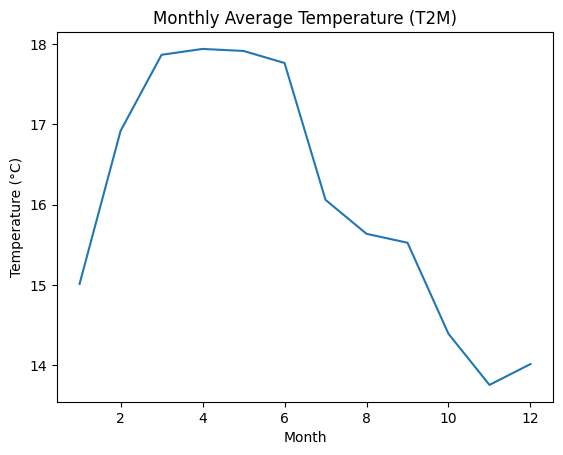

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

Temperature Trend Analysis

- The highest average temperature occurs around month 4.
- The lowest average temperature occurs around between month 10 and 12.
- The pattern shows a clear seasonal trend, with temperatures increasing and decreasing throughout the year.
-This indicates clear climatic seasonality in Ethiopia, with warmer and cooler periods

In [18]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()
monthly_rain

Month
1      138.37
2      352.81
3      667.34
4     1169.67
5     1104.80
6     1735.56
7     3270.52
8     3466.35
9     2106.66
10     567.23
11     226.80
12     121.52
Name: PRECTOTCORR, dtype: float64

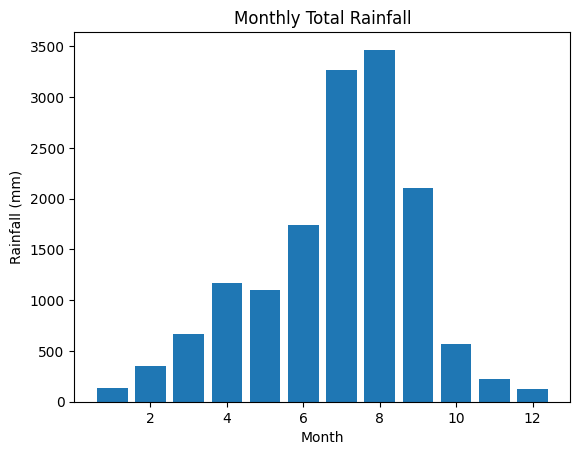

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Total Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

Rainfall Analysis

The highest rainfall occurs in July and August, indicating the peak rainy season.
Rainfall is also relatively high in June and September, showing an extended wet period.
The lowest rainfall occurs in December, January, and November, indicating dry season conditions.
The rainfall pattern is strongly seasonal, with a clear distinction between wet and dry months.

### 5. Correlation and Relationship Analysis

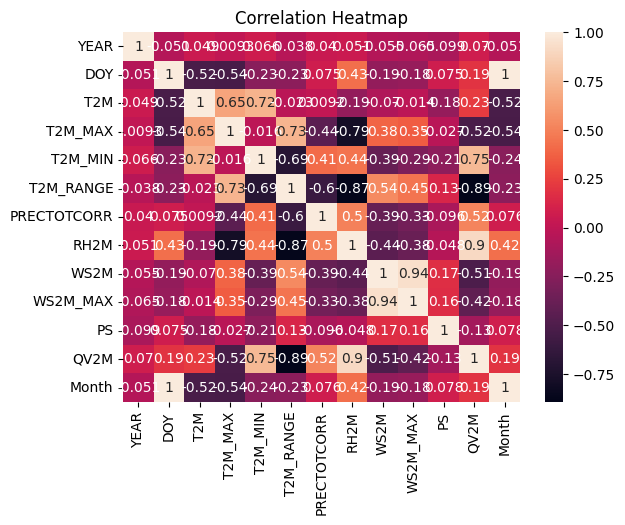

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

 Correlation Analysis

- Strong positive correlations are observed between temperature variables (T2M, T2M_MAX, T2M_MIN).
- Wind variables show moderate positive relationships, indicating consistent wind behavior.
- Temperature and humidity show a negative relationship, which is expected in climate systems.
- Overall, the correlations reflect realistic atmospheric interactions.

### 6. Distribution Analysis

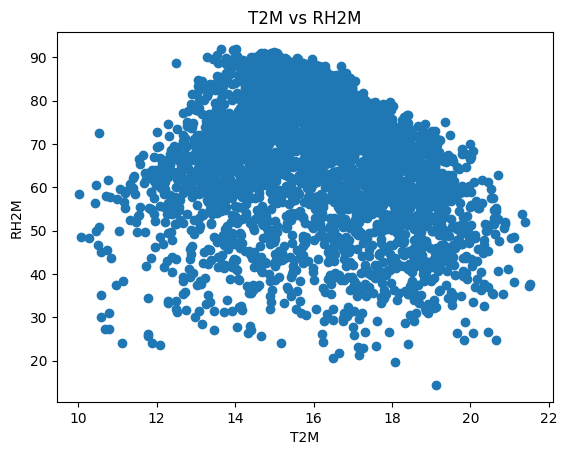

In [21]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("T2M vs RH2M")
plt.show()

Temperature vs Humidity

- There is a weak negative relationship between temperature and humidity.
- Higher temperatures tend to be associated with lower humidity levels.
- This reflects typical atmospheric behavior in warm climates.

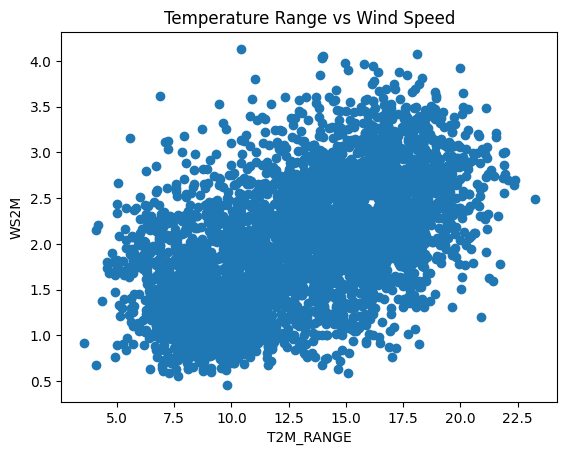

In [22]:
plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.title("Temperature Range vs Wind Speed")
plt.show()

Temperature Range vs Wind Speed

- There is no strong linear relationship between temperature range and wind speed.
- Wind variability appears independent of daily temperature variation.

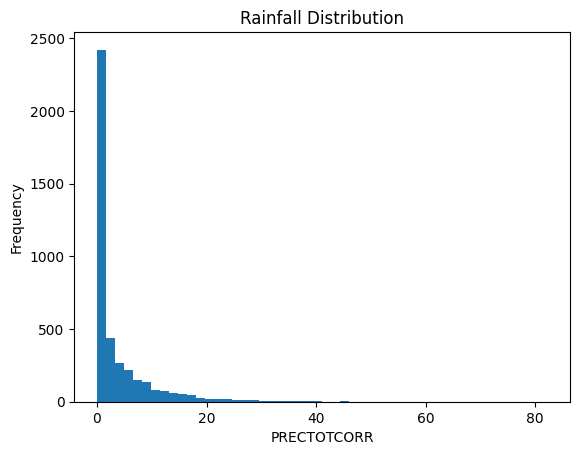

In [23]:
plt.figure()
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.xlabel("PRECTOTCORR")
plt.ylabel("Frequency")
plt.show()

Rainfall Distribution

- Rainfall is highly skewed, with many days having low or zero precipitation.
- A few extreme rainfall events create a long right tail in the distribution.
- This confirms the presence of seasonal and extreme rainfall events.

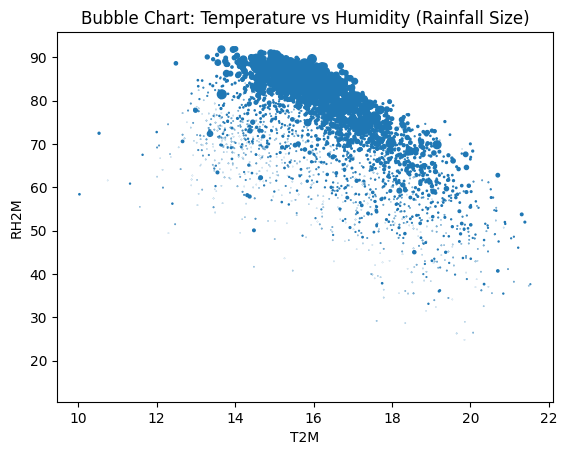

In [24]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Bubble Chart: Temperature vs Humidity (Rainfall Size)")
plt.show()

Bubble Chart Analysis

- The bubble chart shows the relationship between temperature and humidity, with rainfall intensity represented by bubble size.
- Larger bubbles indicate higher rainfall events.
- Rainfall is concentrated in specific temperature and humidity conditions, showing seasonal clustering.